# Задание 1-2

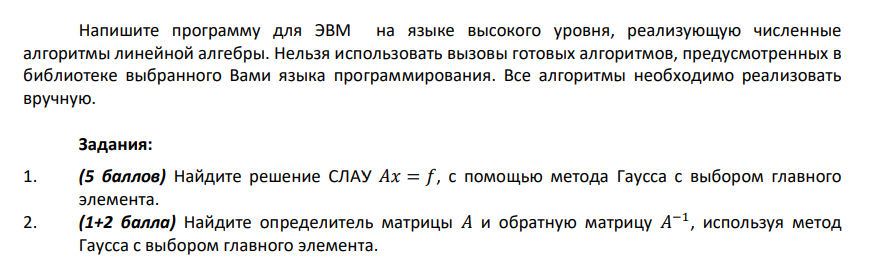

In [1]:
import math
import random

# Базовые векторно-матричные операции (без numpy)
def deep_copy(M):
    return [row[:] for row in M]

def mat_mul_vec(A, x):
    """Умножение матрицы A на вектор x"""
    n = len(A)
    res = [0.0] * n
    
    for i in range(n):
        for j in range(n):
            res[i] += A[i][j] * x[j]
            
    return res

def mat_mul_mat(A, B):
    """Умножение двух матриц A и B"""
    n = len(A)
    C = [[0.0]*n for _ in range(n)]
    
    for i in range(n):
        for k in range(n):
            scalar = A[i][k]
            for j in range(n):
                C[i][j] += scalar * B[k][j]
                
    return C

def vec_sub(v1, v2):
    """Разность векторов v1 - v2"""
    return [a - b for a, b in zip(v1, v2)]

def vec_norm(v):
    """Евклидова норма вектора (длина)"""
    return math.sqrt(sum(x*x for x in v))

def dot_product(v1, v2):
    """Скалярное произведение векторов"""
    return sum(a*b for a, b in zip(v1, v2))

def create_identity(n):
    return [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]

def print_matrix(M, name="Matrix", limit=5):
    print(f"--- {name} (размер {len(M)}x{len(M[0])}) ---")
    rows = min(len(M), limit)
    
    for i in range(rows):
        print([round(x, 4) for x in M[i]])
        
    if len(M) > limit:
        print("...")
        
    print()

# Задания 1 и 2: Метод Гаусса (полный)
def gauss_full(A_in, f_in):
    n = len(A_in)
    A = deep_copy(A_in)
    f = f_in[:] if f_in else [0.0]*n
    I = create_identity(n)
    
    swaps = 0
    
    try:
        # Прямой ход
        for i in range(n):
            # Выбор главного элемента
            pivot = abs(A[i][i])
            pivot_row = i
            for k in range(i+1, n):
                if abs(A[k][i]) > pivot:
                    pivot = abs(A[k][i])
                    pivot_row = k
            
            if pivot < 1e-15:
                # Матрица вырождена
                return None, 0.0, None 
            
            if pivot_row != i:
                A[i], A[pivot_row] = A[pivot_row], A[i]
                f[i], f[pivot_row] = f[pivot_row], f[i]
                I[i], I[pivot_row] = I[pivot_row], I[i]
                swaps += 1
            
            for k in range(i+1, n):
                factor = A[k][i] / A[i][i]
                f[k] -= factor * f[i]
                for j in range(i, n):
                    A[k][j] -= factor * A[i][j]
                for j in range(n):
                    I[k][j] -= factor * I[i][j]

        # Определитель
        det = (-1)**swaps
        for i in range(n):
            det *= A[i][i]

        # Обратный ход (Решение x)
        x = [0.0]*n
        for i in range(n-1, -1, -1):
            sum_ax = sum(A[i][j] * x[j] for j in range(i+1, n))
            x[i] = (f[i] - sum_ax) / A[i][i]
            
        # Обратный ход (Обратная матрица)
        for i in range(n-1, -1, -1):
            for k in range(i-1, -1, -1):
                factor = A[k][i] / A[i][i]
                for j in range(n):
                    I[k][j] -= factor * I[i][j]
        for i in range(n):
            d = A[i][i]
            for j in range(n):
                I[i][j] /= d
                
        return x, det, I
        
    except ZeroDivisionError:
        return None, 0.0, None


# Задание 3
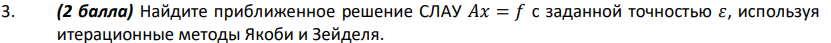

In [2]:

# Задание 3: Метод Якоби и Зейделя
def method_seidel(A, f, eps=1e-6, max_iter=1000):
    n = len(A)
    x = [0.0]*n
    
    for k in range(max_iter):
        x_old = x[:]
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i)) # новые значения
            s2 = sum(A[i][j] * x_old[j] for j in range(i+1, n)) # старые
            
            if abs(A[i][i]) < 1e-15: return None # Деление на ноль
            x[i] = (f[i] - s1 - s2) / A[i][i]
            
        if vec_norm(vec_sub(x, x_old)) < eps:
            return x
    return x

def method_jacobi(A, f, eps=1e-6, max_iter=1000):
    n = len(A)
    x = [0.0]*n
    x_new = [0.0]*n
    
    for k in range(max_iter):
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            if abs(A[i][i]) < 1e-15: return None
            x_new[i] = (f[i] - s) / A[i][i]
        
        if vec_norm(vec_sub(x_new, x)) < eps:
            return x_new
        x = x_new[:]
    return x




# Задание 4
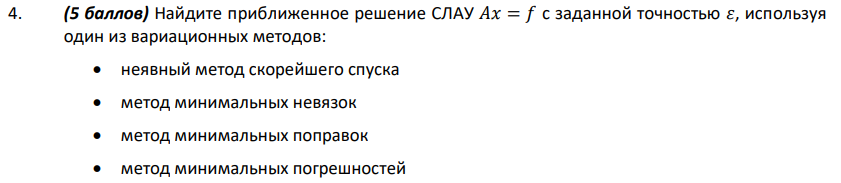

In [3]:
# Задание 4: Вариационный метод (Метод минимальных невязок)
def method_minimal_residuals(A, f, eps=1e-6, max_iter=10000):
    """Метод минимальных невязок для решения Ax=f"""
    n = len(A)
    x = [0.0] * n # Начальное приближение
    
    for k in range(max_iter):
        # r = Ax - f
        Ax = mat_mul_vec(A, x)
        r = vec_sub(Ax, f) 
        
        # Проверка невязки
        if vec_norm(r) < eps:
            return x
            
        # Ar = A * r
        Ar = mat_mul_vec(A, r)
        
        # tau = (Ar, r) / (Ar, Ar)
        numerator = dot_product(Ar, r)
        denominator = dot_product(Ar, Ar)
        
        if denominator < 1e-20: break # Защита
        
        tau = numerator / denominator
        
        # x_{k+1} = x_k - tau * r
        x = [xi - tau * ri for xi, ri in zip(x, r)]
        
    return x

# Тесты

In [5]:

def run_test(name, A, f_exact=None):
    print(f"\n{'='*20} {name} {'='*20}")
    n = len(A)
    
    # Если точного решения нет, придумаем f сами
    # Пусть точное решение x = [1, 1, ..., 1]
    if f_exact is None:
        x_true = [1.0] * n
        f = mat_mul_vec(A, x_true)
        print("Вектор f сгенерирован для точного решения x=[1, 1...]")
    else:
        f = f_exact
        x_true = None

    # 1. Метод Гаусса
    x_gauss, det, inv_A = gauss_full(A, f)
    
    if x_gauss is None:
        print("[!] Матрица вырождена, метод Гаусса не применим.")
    else:
        # Проверка невязки
        # f1 = A * x_calc
        # delta = ||f - f1||
        f_calc = mat_mul_vec(A, x_gauss)
        delta = vec_norm(vec_sub(f, f_calc))
        
        print(f"1. Гаусс | Det: {det:.2e} | Погрешность решения (delta): {delta:.2e}")
        
        # Проверка обратной матрицы 
        # A * A^-1 = E
        if inv_A:
            prod = mat_mul_mat(A, inv_A)
            # Проверяем первый элемент и диагональ
            is_identity = abs(prod[0][0] - 1.0) < 1e-9
            print(f"2. Обратная матрица | A*A^-1[0][0] = {prod[0][0]:.6f} (Должно быть 1.0)")
    
    # 3. Итерационные методы
    print("3. Итерационные методы (Зейдель):")
    x_seidel = method_seidel(A, f)
    if x_seidel:
        f_s = mat_mul_vec(A, x_seidel)
        delta_s = vec_norm(vec_sub(f, f_s))
        print(f"   Погрешность (delta): {delta_s:.2e}")
    else:
        print("   Метод не применим (деление на 0)")

    # 4. Вариационный метод
    print("4. Метод минимальных невязок:")
    x_var = method_minimal_residuals(A, f)
    f_v = mat_mul_vec(A, x_var)
    delta_v = vec_norm(vec_sub(f, f_v))
    print(f"   Погрешность (delta): {delta_v:.2e}")
    
# 1. Матрица заданная явно (Тестовый вариант)
A_simple = [[4, 1, 1], [1, 6, 2], [1, 2, 6]]
run_test("Явная матрица (диаг. преобладание)", A_simple)

# 2. Матрица Гильберта (Плохо обусловленная)
# H_ij = 1 / (i + j + 1)
n_hilb = 4
A_hilb = [[1.0 / (i + j + 1) for j in range(n_hilb)] for i in range(n_hilb)]
run_test("Матрица Гильберта (4x4)", A_hilb)

# 3. Единичная матрица
A_identity = create_identity(4)
run_test("Единичная матрица", A_identity)

# 4. Вырожденная матрица (нулевая строка)
A_deg = [[1, 2, 3], [4, 5, 6], [0, 0, 0]]
run_test("Вырожденная матрица (нулевая строка)", A_deg)

# 5. Случайная матрица
n_rand = 5
A_rand = [[random.uniform(-10, 10) for _ in range(n_rand)] for _ in range(n_rand)]
run_test("Случайная матрица (5x5)", A_rand)


==================== Явная матрица (диаг. преобладание) ====================
Вектор f сгенерирован для точного решения x=[1, 1...]
1. Гаусс | Det: 1.20e+02 | Погрешность решения (delta): 0.00e+00
2. Обратная матрица | A*A^-1[0][0] = 1.000000 (Должно быть 1.0)
3. Итерационные методы (Зейдель):
   Погрешность (delta): 1.32e-07
4. Метод минимальных невязок:
   Погрешность (delta): 2.18e-07

==================== Матрица Гильберта (4x4) ====================
Вектор f сгенерирован для точного решения x=[1, 1...]
1. Гаусс | Det: 1.65e-07 | Погрешность решения (delta): 2.48e-16
2. Обратная матрица | A*A^-1[0][0] = 1.000000 (Должно быть 1.0)
3. Итерационные методы (Зейдель):
   Погрешность (delta): 7.92e-06
4. Метод минимальных невязок:
   Погрешность (delta): 1.00e-06

==================== Единичная матрица ====================
Вектор f сгенерирован для точного решения x=[1, 1...]
1. Гаусс | Det: 1.00e+00 | Погрешность решения (delta): 0.00e+00
2. Обратная матрица | A*A^-1[0][0] = 1.000000 (До